# Top+Side View Volume Estimation
# Frozen Feature Extractor + POV Fusion + Regression Head
# General Performance Evaluation

This notebook trains and evaluates different combinations of frozen feature extractors, POV fusion strategies, and regression heads on the top+side dataset.


In [1]:
import datetime
import json
import warnings
from IPython.display import display
from sklearn.model_selection import ParameterGrid
from src.helpers import *
from src.frozen_pipeline import *
from src.training_and_evaluation import *
from src.constants import *

warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 200)

/home/lenka-hake/Documents/CV/ComputerVisionProject/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:184: UserWarning: CUDA initialization: CUDA unknown error - this may be due to an incorrectly set up environment, e.g. changing env variable CUDA_VISIBLE_DEVICES after program start. Setting the available devices to be zero. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


## Load Data


In [2]:
samples, image_paths = load_image_paths(CSV_PATH, TOP_FOLDER, SIDE_FOLDER)
print("Samples shape:", samples.shape)
display(samples[["exp_id", "volume", "top_path", "side_path"]].head(8))

Samples shape: (420, 24)


,exp_id,volume,top_path,side_path
0,1,1.06,photos/top_view_images/P2260331.JPG,photos/side_view_images/P2260685.JPG
1,1,2.12,photos/top_view_images/P2260332.JPG,photos/side_view_images/P2260686.JPG
2,1,3.18,photos/top_view_images/P2260333.JPG,photos/side_view_images/P2260687.JPG
3,1,4.24,photos/top_view_images/P2260334.JPG,photos/side_view_images/P2260688.JPG
4,2,1.06,photos/top_view_images/P2260335.JPG,photos/side_view_images/P2260689.JPG
5,2,2.12,photos/top_view_images/P2260336.JPG,photos/side_view_images/P2260690.JPG
6,2,3.18,photos/top_view_images/P2260337.JPG,photos/side_view_images/P2260692.JPG
7,2,4.24,photos/top_view_images/P2260339.JPG,photos/side_view_images/P2260693.JPG


## Show Regression Model Configurations


In [3]:
print("Grid sizes per regressor:")
for name, (_, grid) in ALL_REGRESSION_MODEL_CONFIGS.items():
    n = len(list(ParameterGrid(grid))) if grid else 1
    print(f"  {name:15s}: {n:4d}")

Grid sizes per regressor:
  linear         :    1
  ridge          :    7
  elasticnet     :   16
  random_forest  :    4
  mlp            :   18


## Nested CV Evaluation (split by experiment IDs) - Backbone X Fusion Mode X Regression Model

In [4]:
all_results = []
nested_artifacts = {}

for backbone_name in ALL_BACKBONE_NAMES:
    embedding_memory_cache = {}

    for fusion_name in ALL_FUSION_NAMES:
        print(f"\n{'#'*90}")
        print(f"Evaluating backbone={backbone_name}, fusion={fusion_name}")
        print(f"{'#'*90}")

        X, y, groups = build_feature_matrix(
            samples,
            backbone_name,
            fusion_name,
            EMBEDDING_CACHE_DIR,
            DEVICE,
            top_mask_paths=TOP_ROI_MASKS,
            side_mask_paths=SIDE_ROI_MASKS,
            embedding_memory_cache=embedding_memory_cache
        )

        nested_results, oof_predictions = run_nested_cv(
            X=X,
            y=y,
            groups=groups,
            model_configs=ALL_REGRESSION_MODEL_CONFIGS,
            outer_splits=OUTER_SPLITS,
            inner_splits=INNER_SPLITS
        )

        summary_df = summarise_nested_results(nested_results, backbone_name, fusion_name)
        all_results.append(summary_df)
        nested_artifacts[(backbone_name, fusion_name)] = {
            "X": X,
            "y": y,
            "groups": groups,
            "nested_results": nested_results,
            "oof_predictions": oof_predictions,
        }

results_df = pd.concat(all_results, ignore_index=True).sort_values(
    ["cv_mae_mean", "cv_rmse_mean", "cv_r2_mean"],
    ascending=[True, True, False],
).reset_index(drop=True)


##########################################################################################
Evaluating backbone=resnet50, fusion=concat
##########################################################################################


resnet50 + concat: 100%|██████████| 420/420 [00:00<00:00, 2311.95it/s]


GroupKFold | linear


Fold 1: MAE=0.307, RMSE=0.395, R2=0.8930483293732745, best={}
Fold 2: MAE=0.300, RMSE=0.398, R2=0.8913738187445863, best={}
Fold 3: MAE=0.328, RMSE=0.426, R2=0.8754156020141597, best={}
Fold 4: MAE=0.324, RMSE=0.390, R2=0.89139881852174, best={}
Fold 5: MAE=0.417, RMSE=0.530, R2=0.7915520504411295, best={}

GroupKFold | ridge
Fold 1: MAE=0.318, RMSE=0.401, R2=0.8897104388026574, best={'model__alpha': 1000.0}
Fold 2: MAE=0.297, RMSE=0.394, R2=0.893495312783288, best={'model__alpha': 1000.0}
Fold 3: MAE=0.327, RMSE=0.425, R2=0.8756422651391698, best={'model__alpha': 10.0}
Fold 4: MAE=0.323, RMSE=0.390, R2=0.891494935490386, best={'model__alpha': 1000.0}
Fold 5: MAE=0.416, RMSE=0.528, R2=0.7932152975273776, best={'model__alpha': 100.0}

GroupKFold | elasticnet
Fold 1: MAE=0.324, RMSE=0.402, R2=0.8887104679804285, best={'model__alpha': 0.1, 'model__l1_ratio': 0.1}
Fold 2: MAE=0.348, RMSE=0.432, R2=0.8720721817287049, best={'model__alpha': 0.1, 'model__l1_ratio': 0.1}
Fold 3: MAE=0.337, RMS

resnet50 + mean: 100%|██████████| 420/420 [00:00<00:00, 3593.07it/s]

...


GroupKFold | linear
Fold 1: MAE=0.442, RMSE=0.569, R2=0.7775482947998582, best={}
Fold 2: MAE=0.435, RMSE=0.515, R2=0.8176226453233735, best={}
Fold 3: MAE=0.354, RMSE=0.467, R2=0.8500886803927241, best={}


Fold 4: MAE=0.430, RMSE=0.545, R2=0.7885609235883221, best={}
Fold 5: MAE=0.394, RMSE=0.492, R2=0.820511521554446, best={}

GroupKFold | ridge
Fold 1: MAE=0.348, RMSE=0.446, R2=0.863176652937197, best={'model__alpha': 1000.0}
Fold 2: MAE=0.326, RMSE=0.422, R2=0.8774102127277161, best={'model__alpha': 1000.0}
Fold 3: MAE=0.311, RMSE=0.402, R2=0.8889744916904564, best={'model__alpha': 100.0}
Fold 4: MAE=0.360, RMSE=0.462, R2=0.8475839664529023, best={'model__alpha': 100.0}
Fold 5: MAE=0.394, RMSE=0.488, R2=0.8233608405088565, best={'model__alpha': 1000.0}

GroupKFold | elasticnet
Fold 1: MAE=0.352, RMSE=0.453, R2=0.8587554443214572, best={'model__alpha': 0.1, 'model__l1_ratio': 0.2}
Fold 2: MAE=0.314, RMSE=0.414, R2=0.8819623777310017, best={'model__alpha': 0.1, 'model__l1_ratio': 0.2}
Fold 3: MAE=0.299, RMSE=0.384, R2=0.8986768100356605, best={'model__alpha': 0.1, 'model__l1_ratio': 0.2}
Fold 4: MAE=0.363, RMSE=0.451, R2=0.8548811813555783, best={'model__alpha': 0.1, 'model__l1_ratio': 

vit_b_16 + concat_abs_diff: 100%|██████████| 420/420 [00:00<00:00, 4112.97it/s]


GroupKFold | linear
Fold 1: MAE=0.399, RMSE=0.504, R2=0.8258167220465321, best={}


Fold 2: MAE=0.346, RMSE=0.440, R2=0.8671461321409697, best={}
Fold 3: MAE=0.371, RMSE=0.462, R2=0.8535770031373506, best={}
Fold 4: MAE=0.356, RMSE=0.456, R2=0.8516043433866207, best={}
Fold 5: MAE=0.368, RMSE=0.458, R2=0.8443152441055333, best={}

GroupKFold | ridge
Fold 1: MAE=0.357, RMSE=0.463, R2=0.8525746053368191, best={'model__alpha': 1000.0}
Fold 2: MAE=0.307, RMSE=0.407, R2=0.8862925020445658, best={'model__alpha': 1000.0}
Fold 3: MAE=0.340, RMSE=0.432, R2=0.8720576350682918, best={'model__alpha': 1000.0}
Fold 4: MAE=0.336, RMSE=0.413, R2=0.878572469324914, best={'model__alpha': 1000.0}
Fold 5: MAE=0.360, RMSE=0.447, R2=0.8522006540884911, best={'model__alpha': 1000.0}

GroupKFold | elasticnet
Fold 1: MAE=0.368, RMSE=0.469, R2=0.8488994028377552, best={'model__alpha': 0.1, 'model__l1_ratio': 0.2}
Fold 2: MAE=0.320, RMSE=0.433, R2=0.8712004029159315, best={'model__alpha': 0.1, 'model__l1_ratio': 0.2}
Fold 3: MAE=0.332, RMSE=0.409, R2=0.8850165186939762, best={'model__alpha': 0.

## Add Dummy Mean Predictions for Comparison

In [5]:
dummy_pred = np.full(len(samples), samples["volume"].mean(), dtype=float)
dummy_mae = mean_absolute_error(samples["volume"], dummy_pred)
dummy_mse = mean_squared_error(samples["volume"], dummy_pred)
dummy_rmse = np.sqrt(dummy_mse)
dummy_r2 = r2_score(samples["volume"], dummy_pred)

dummy_row = pd.DataFrame([{
    "backbone": "dummy_mean",
    "fusion": "dummy_mean",
    "regressor": "dummy_mean",
    "cv_mae_mean": dummy_mae,
    "cv_mae_std": 0.0,
    "cv_mse_mean": dummy_mse,
    "cv_mse_std": 0.0,
    "cv_rmse_mean": dummy_rmse,
    "cv_rmse_std": 0.0,
    "cv_r2_mean": dummy_r2,
    "cv_r2_std": 0.0,
}])

results_df = pd.concat([results_df, dummy_row], ignore_index=True).sort_values(
    ["cv_mae_mean", "cv_rmse_mean", "cv_r2_mean"],
    ascending=[True, True, False],
).reset_index(drop=True)

## Show Selected Hyperparameters


In [6]:
for (backbone_name, fusion_name), artifact in nested_artifacts.items():
    print(f"\n{'='*90}")
    print(f"backbone={backbone_name}, fusion={fusion_name}")
    print(f"{'='*90}")
    for regressor_name, folds in artifact["nested_results"].items():
        has_params = any(f["best_params"] for f in folds)
        if not has_params:
            continue
        print(regressor_name)
        for f in folds:
            print(f"  Fold {f['fold']}: {f['best_params']}")
        print()


backbone=resnet50, fusion=concat
ridge
  Fold 1: {'model__alpha': 1000.0}
  Fold 2: {'model__alpha': 1000.0}
  Fold 3: {'model__alpha': 10.0}
  Fold 4: {'model__alpha': 1000.0}
  Fold 5: {'model__alpha': 100.0}

elasticnet
  Fold 1: {'model__alpha': 0.1, 'model__l1_ratio': 0.1}
  Fold 2: {'model__alpha': 0.1, 'model__l1_ratio': 0.1}
  Fold 3: {'model__alpha': 0.1, 'model__l1_ratio': 0.5}
  Fold 4: {'model__alpha': 0.1, 'model__l1_ratio': 0.2}
  Fold 5: {'model__alpha': 0.1, 'model__l1_ratio': 0.2}

random_forest
  Fold 1: {'model__max_features': 0.5, 'model__min_samples_leaf': 2}
  Fold 2: {'model__max_features': 0.3, 'model__min_samples_leaf': 2}
  Fold 3: {'model__max_features': 0.5, 'model__min_samples_leaf': 2}
  Fold 4: {'model__max_features': 0.5, 'model__min_samples_leaf': 2}
  Fold 5: {'model__max_features': 0.3, 'model__min_samples_leaf': 2}

mlp
  Fold 1: {'model__alpha': 0.001, 'model__hidden_layer_sizes': (128,), 'model__learning_rate_init': 0.0003}
  Fold 2: {'model__alph

## Show Performance for All Configurations (best at the top)
Prints mean and standard deviation of MAE, MSE, RMSE, and R2 over the CV folds. Plots out-of-fold predictions for the best configurations.


,backbone,fusion,regressor,cv_mae_mean,cv_mae_std,cv_mse_mean,cv_mse_std,cv_rmse_mean,cv_rmse_std,cv_r2_mean,cv_r2_std
0,densenet121,concat,ridge,0.258130,0.035248,0.110834,0.032472,0.329684,0.046284,0.921515,0.025534
1,densenet121,concat,linear,0.265728,0.033390,0.118111,0.031906,0.340763,0.044628,0.916445,0.025050
2,densenet121,concat,elasticnet,0.266106,0.038978,0.116958,0.033627,0.338597,0.048063,0.917275,0.026138
3,densenet121,concat_abs_diff,ridge,0.267193,0.035690,0.118619,0.032201,0.341502,0.044667,0.916025,0.025555
4,densenet121,concat_abs_diff,linear,0.271169,0.034352,0.121325,0.033215,0.345262,0.046039,0.914122,0.026221
5,densenet121,concat_abs_diff,elasticnet,0.273955,0.041067,0.122553,0.035230,0.346580,0.049343,0.913315,0.027375
6,densenet121,mean,ridge,0.284240,0.039026,0.134473,0.036538,0.363677,0.047038,0.904890,0.028863
7,densenet121,max,ridge,0.286150,0.028710,0.135423,0.028706,0.366047,0.037855,0.904342,0.023016
8,densenet121,max,elasticnet,0.288382,0.051105,0.140964,0.045399,0.371212,0.056266,0.900111,0.035614
9,densenet121,mean,elasticnet,0.291225,0.047460,0.143736,0.049648,0.374398,0.059687,0.898002,0.039035


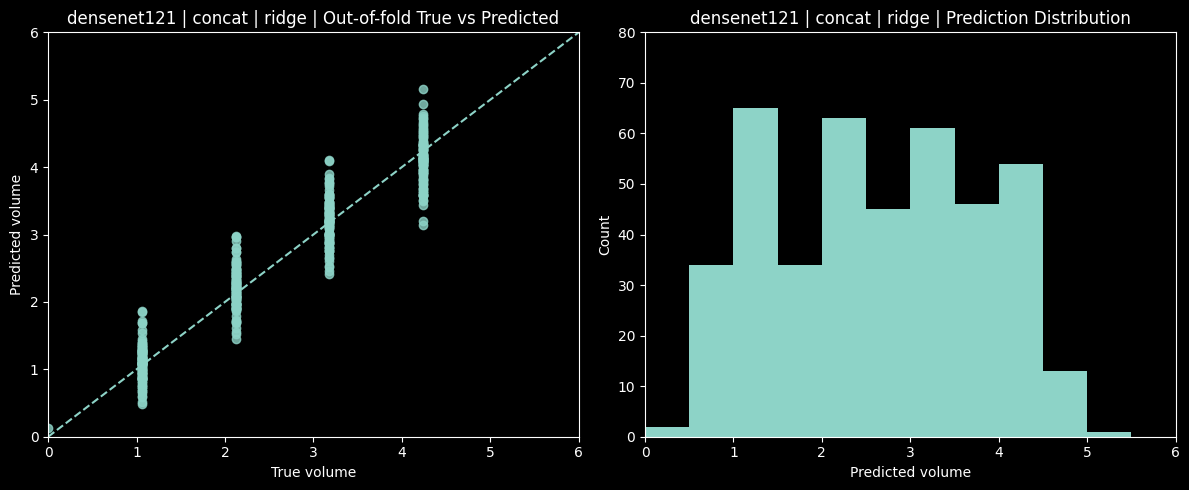

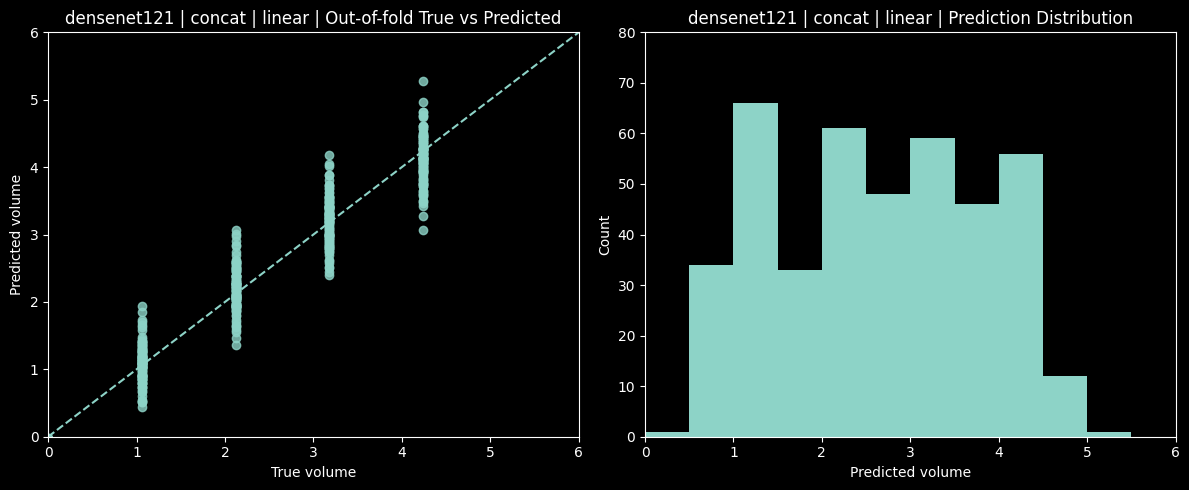

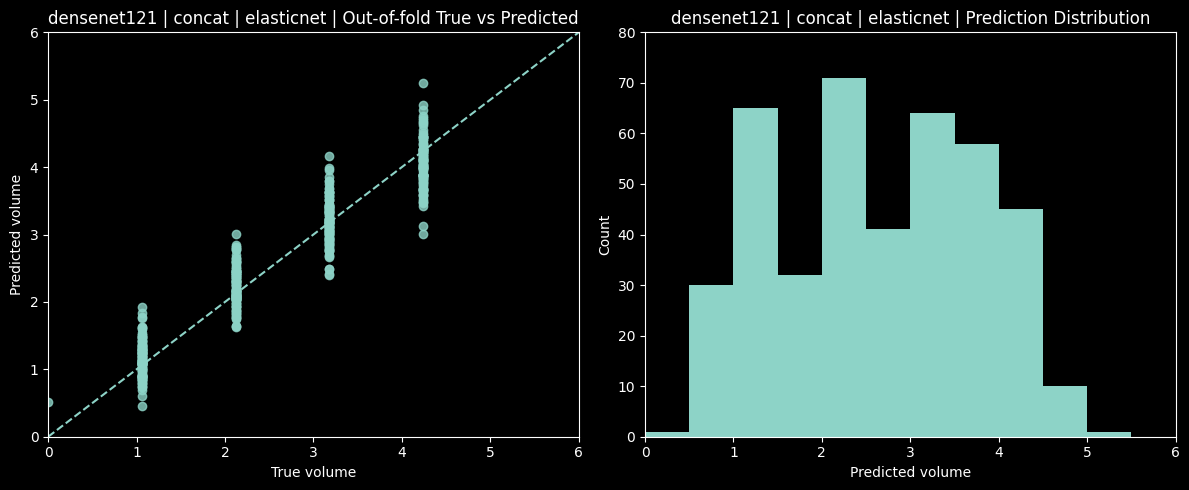

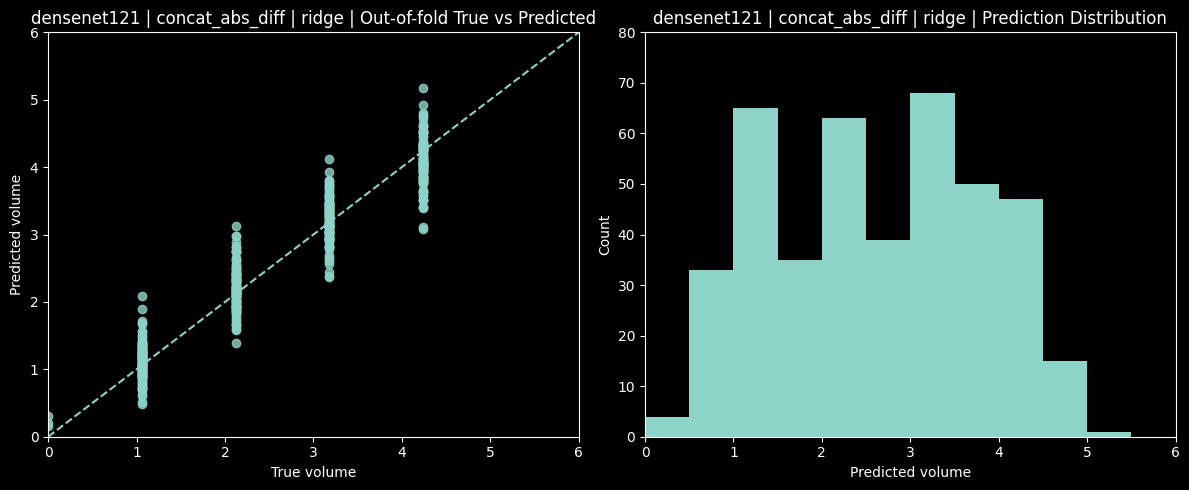

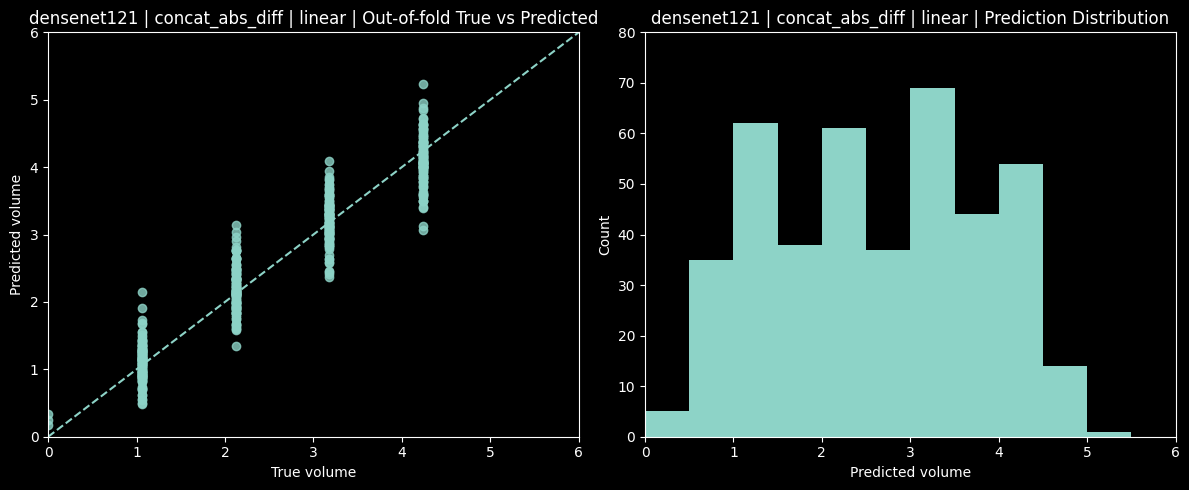

In [10]:
pd.set_option("display.max_rows", None)
display(results_df)
pd.reset_option("display.max_rows")

for _, row in results_df.head(5).iterrows():
    key = (row["backbone"], row["fusion"])
    if key in nested_artifacts:
        artifact = nested_artifacts[key]
        y_true = artifact["y"]
        y_pred = artifact["oof_predictions"][row["regressor"]]
        title = f"{row['backbone']} | {row['fusion']} | {row['regressor']}"
        make_oof_plot(y_true, y_pred, title_prefix=title)


## Compare Backbones Across Configurations

In [17]:
backbone_summary = (
    results_df.groupby("backbone")
    .agg(
        best_mae=("cv_mae_mean", "min"),
        mean_mae=("cv_mae_mean", "mean")
    )
)

top_k = results_df.nsmallest(10, "cv_mae_mean")
top_k_counts = top_k["backbone"].value_counts()

backbone_summary["top_k_count"] = backbone_summary.index.map(top_k_counts).fillna(0).astype(int)
backbone_summary = backbone_summary.sort_values(["best_mae"])

display(backbone_summary)

,best_mae,mean_mae,top_k_count
backbone,,,
densenet121,0.258130,0.368547,10
convnext_tiny,0.296429,0.390305,0
resnet50,0.329139,0.469908,0
vit_b_16,0.333002,0.430235,0
dummy_mean,1.061442,1.061442,0


## Compare Fusions Across Configurations

In [18]:
fusion_summary = (
    results_df.groupby("fusion")
    .agg(
        best_mae=("cv_mae_mean", "min"),
        mean_mae=("cv_mae_mean", "mean")
    )
)

top_k_counts = top_k["fusion"].value_counts()

fusion_summary["top_k_count"] = fusion_summary.index.map(top_k_counts).fillna(0).astype(int)
fusion_summary = fusion_summary.sort_values(["best_mae"])

display(fusion_summary)

,best_mae,mean_mae,top_k_count
fusion,,,
concat,0.258130,0.419513,3
concat_abs_diff,0.267193,0.416814,3
mean,0.284240,0.404985,2
max,0.286150,0.417683,2
dummy_mean,1.061442,1.061442,0


## Compare Regressors Across Configurations

In [19]:
regressor_summary = (
    results_df.groupby("regressor")
    .agg(
        best_mae=("cv_mae_mean", "min"),
        mean_mae=("cv_mae_mean", "mean")
    )
)

top_k_counts = top_k["regressor"].value_counts()

regressor_summary["top_k_count"] = regressor_summary.index.map(top_k_counts).fillna(0).astype(int)
regressor_summary = regressor_summary.sort_values(["best_mae"])

display(regressor_summary)

,best_mae,mean_mae,top_k_count
regressor,,,
ridge,0.258130,0.314049,4
linear,0.265728,0.340916,2
elasticnet,0.266106,0.319281,4
random_forest,0.351721,0.406935,0
mlp,0.507960,0.692563,0
dummy_mean,1.061442,1.061442,0


## Save results


In [24]:
timestamp = datetime.datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
name = f"top_side_frozen_performance_{timestamp}.csv"
results_df.to_csv(OUTPUT_DIR / name, index=False)
print("Saved:", OUTPUT_DIR / name)

hyperparams_name = f"top_side_frozen_performance_best_hyperparameters_{timestamp}.json"

best_hyperparameters = {}
for (backbone_name, fusion_name), artifact in nested_artifacts.items():
    config_key = f"{backbone_name}__{fusion_name}"
    best_hyperparameters[config_key] = {}
    for regressor_name, folds in artifact["nested_results"].items():
        fold_params = [
            {
                "fold": f["fold"],
                "best_params": f["best_params"],
                "MAE": f.get("MAE"),
                "RMSE": f.get("RMSE"),
                "R2": f.get("R2"),
                "MSE": f.get("MSE"),
            }
            for f in folds
            if f.get("best_params")
        ]

        best_hyperparameters[config_key][regressor_name] = fold_params

with open(OUTPUT_DIR / hyperparams_name, "w") as f:
    json.dump(best_hyperparameters, f, indent=2, default=str)

print("Saved:", OUTPUT_DIR / hyperparams_name)

oof_rows = []
sample_meta = samples[["file_name", "exp_id", "volume", "top_path", "side_path"]].reset_index(drop=True)

for (backbone_name, fusion_name), artifact in nested_artifacts.items():
    for regressor_name, y_pred in artifact["oof_predictions"].items():
        y_true = artifact["y"]
        for i, (yt, yp) in enumerate(zip(y_true, y_pred)):
            oof_rows.append({
                "backbone": backbone_name,
                "fusion": fusion_name,
                "regressor": regressor_name,
                "sample_idx": i,
                "exp_id": sample_meta.loc[i, "exp_id"],
                "top_path": sample_meta.loc[i, "top_path"],
                "side_path": sample_meta.loc[i, "side_path"],
                "volume": sample_meta.loc[i, "volume"],
                "y_true": float(yt),
                "y_pred": float(yp),
                "residual": float(yp - yt),
                "abs_error": float(abs(yp - yt)),
            })

oof_df = pd.DataFrame(oof_rows)
oof_name = f"top_side_frozen_performance_oof_predictions_{timestamp}.csv"
oof_df.to_csv(OUTPUT_DIR / oof_name, index=False)

print("Saved:", OUTPUT_DIR / oof_name)

Saved: results/top_side_frozen_performance_2026-04-02_01-09-03.csv
Saved: results/top_side_frozen_performance_best_hyperparameters_2026-04-02_01-09-03.json
Saved: results/top_side_frozen_performance_oof_predictions_2026-04-02_01-09-03.csv
